# LLM(Large Language Model)

방대한 텍스트 데이터를 학습해 다음에 올 단어를 확률적으로 예측하는 ‘초거대 언어모델’

- 지식의 압축: 인터넷상의 방대한 정보를 신경망 파라미터(가중치) 안에 압축하여 저장한 형태이다.
- 패턴 인식: 단순 암기가 아니라, 언어의 문맥과 패턴을 파악하여 추론(Inference)하는 능력을 갖추고 있다.
- 확률적 생성: 정해진 답을 출력하는 것이 아니라, 문맥상 가장 적절할 확률이 높은 단어를 선택하여 문장을 만들어낸다.

### 모델 파라미터에 따른 LLM 구분

LLM(대규모 언어 모델)은 주로 모델 파라미터(매개변수, parameters)의 개수에 따라 모델의 크기와 성능이 구분된다.  
파라미터 수가 많을수록 일반적으로 더 복잡하고 다양한 언어 패턴을 학습할 수 있으며, 성능도 향상되는 경향이 있다.

- SLM(6.7B ~ 30B)은 파인튜닝 후 일반 성능이 떨어지는 경우가 많다. 특히 10B 미만의 모델들이 더 그렇다.

| 구분 | 대략 파라미터 범위 | 특징 요약 |
|------|------------------|----------|
| LLM | 100B ~ 1T+ | 최고 성능, 고비용·고자원 필요 |
| sLLM | 대략 13B ~ 30B | LLM 수준 유지, 성능·자원 균형 |
| SLM | 3B ~ 13B (또는 최대 30B 정도) | 경량 GPU/디바이스 가능, 도메인 특화 |
| 초소형/에지모델 | 수천만 ~ 수억 | 임베디드, 빠른 응답, 특정 작업 위주 |

### open/close-source 여부에 따른 LLM 구분

LLM은 공개 범위와 활용 방식에 따라 크게 **개방형(Open Source, 오픈소스)** 과  
**폐쇄형(Closed Source, 특정/상용)** 으로 구분할 수 있다.

| 구분 | 개방형(Open Source) LLM | 폐쇄형(Closed Source) LLM |
|------|------------------------|---------------------------|
| 라이선스 | 오픈소스 라이선스(Apache, MIT 등) | 벤더 라이선스, 상용 API 기반 |
| 모델 접근 | 소스 코드, 가중치, 아키텍처 모두 공개 | 내부 구조/가중치 비공개, API로만 접근 |
| 커스터마이징 | 자유롭게 수정 및 파인튜닝 가능 | 제한적, 벤더가 허용한 범위 내에서만 가능 |
| 기술 지원 | 커뮤니티 중심, 자율적 해결 | 벤더의 공식 지원, SLA 제공 |
| 보안/프라이버시 | 자체 서버 배포 가능, 맞춤형 보안 적용 | 벤더 인프라 의존, 데이터 외부 전송 필요 |
| 비용 구조 | 인프라 직접 비용, 무료 활용 가능 | API 호출 기반 과금, 구독 등 상용 모델 |

- 대표 예시  
  - 개방형: Meta LLaMA, Mistral, GPT-NeoX 등  
  - 폐쇄형: OpenAI GPT-3/4, Google Gemini, Anthropic Claude 등  

- 개방형 LLM은 연구자와 개발자가 자유롭게 모델을 활용·수정할 수 있어 빠른 혁신과 다양한 커스터마이징이 가능하다. 단, 자체 운영·관리 역량이 필요하다.  
- 폐쇄형 LLM은 벤더가 모델을 소유·운영하며, 사용자는 API 형태로 접근한다. 보안, 신뢰성, 공식 지원이 강점이나 내부 구조나 가중치 접근이 제한된다.

## LLM 학습 과정

### 1. 사전 학습 (Pre-training)

- 학습 내용: 방대한 텍스트 데이터를 통해 언어의 전반적인 패턴과 지식을 습득
- 학습 방식: 다음에 올 단어 예측 방식 (Self-supervised Learning)
- 결과물: Base Model (문장 이어쓰기 능력)

### 2. 지도 미세 조정 (SFT: Supervised Fine-Tuning)

- 학습 내용: 질문-답변(Instruction) 및 대화(Multi-turn) 데이터셋 학습
- 학습 목표: 사용자 의도와 대화의 문맥을 파악하는 능력 배양
- 결과물: Instruct Model (챗봇 형태)

### 3. 가치 정렬 (Alignment)

- 학습 목표: 인간의 가치와 의도(Helpful, Honest, Harmless)에 부합하도록 모델 조율

- 학습 방법:
  - 전통적 방식 (RLHF/PPO): 별도의 보상 모델(Reward Model)을 이용한 강화학습
  - 최신 트렌드 (DPO/ORPO): 보상 모델 없이 선호 데이터(Preference Data)를 직접 학습하여 효율성 증대

- 결과물: Aligned Model (최종 배포용)

## In-context Learning

**In-Context Learning (ICL)** 은 거대 언어 모델(LLM)이 모델의 가중치(Weight) 업데이트 없이, 프롬프트 내에 주어진 예시나 설명을 문맥(Context)으로 파악하여 즉석에서 새로운 작업을 수행하는 방법론이다.

이는 GPT-3 논문에서 제시된 개념으로, 데이터의 오차를 역전파(Backpropagation)하여 파라미터를 수정하는 기존의 Fine-tuning과는 근본적으로 다른 패러다임이다.

- 작동 원리 (Bayesian Inference): 모델은 방대한 사전 학습을 통해 수많은 태스크의 분포를 학습했다. ICL은 프롬프트를 통해 모델이 알고 있는 지식 공간에서 현재 태스크와 가장 유사한 분포를 상기(Recall)시키는 과정으로 해석된다.

- 한계점:
  - Context Window 제한: 입력할 수 있는 예시의 양이 모델의 최대 토큰 길이에 의해 제한된다.
  - 민감성: 예시의 순서, 라벨링의 정확도, 포맷팅 등 프롬프트 구성의 미세한 차이에 따라 성능 변동이 크다.

### 1. 핵심 메커니즘: 학습이 아닌 ‘패턴 인식’

ICL의 본질은 모델이 새로운 지식을 ‘학습’하는 것이 아니라, 이미 학습된 능력(Next Token Prediction)을 활용해 입력된 텍스트의 패턴을 모방하는 것이다.

- 비유: 시험공부(Fine-tuning) 없이, 시험지의 ‘보기 문제’를 보고 푸는 요령을 즉석에서 파악하여 답안을 작성하는 것과 같다.
- 작동 방식: 모델은 입력된 Context 안에서 Input Output의 규칙성을 발견하고, 그 패턴을 이어가는 방식으로 추론한다.

### 2. Shot의 개념 (예시의 양에 따른 분류)

모델에게 제공하는 예시(Demonstration)의 수에 따라 다음과 같이 구분한다.

- Zero-shot Learning: 예시 없이 지시문(Instruction)만 제공한다. 모델의 사전 지식(Pre-trained knowledge)에 전적으로 의존한다.
- One-shot Learning: 단 하나의 예시를 보여주어 작업의 성격을 유추하게 한다.
- Few-shot Learning: 다수(보통 10~100개)의 예시를 제공하여 패턴을 명확히 학습하게 한다. 일반적으로 가장 높은 성능을 보인다.

### 3. ICL vs. Fine-tuning 비교

| 구분 | Fine-tuning (전통적 방식) | In-Context Learning (ICL) |
|------|---------------------------|---------------------------|
| 파라미터 업데이트 | 있음 (가중치 변경) | 없음 (가중치 고정) |
| 데이터 요구량 | 수천~수만 건 이상 | 0~수십 건 (프롬프트 내) |
| 적용성 | 태스크마다 모델 재학습 필요 | 프롬프트 수정만으로 즉시 전환 가능 |
| 비용 | 높은 학습 비용 및 시간 소요 | 추론(Inference) 비용만 발생 |

## Emergent Abilities 창발능력

https://openreview.net/pdf?id=yzkSU5zdwD

**창발 능력(Emergent Abilities)** 이란, AI 모델의 크기(파라미터 수, 데이터 양)가 특정 임계치를 넘어서면서 작은 모델에서는 없던 능력이 갑자기 발현되는 현상이다.  
"양이 일정 수준 쌓이면 질적인 변화가 일어난다"는 개념과 유사하다.

- 비선형적 점증: 성능이 서서히 증가하는 것이 아니라, 그래프가 계단식으로 향상된다.
- 예측 불가능성: 작은 모델의 결과만으로는 거대 모델에서 어떤 능력이 생길지 예측하기 어렵다.
- 규모 의존: 주로 수천억 개 이상의 파라미터를 가진 초거대 모델에서 관찰된다.

대표 예시:

- 단계적 추론(Chain-of-Thought): 복잡한 문제를 논리적 단계로 쪼개어 해결하는 능력이다.
- Few-shot Learning: 별도의 재학습 없이 예시 몇 개만으로 새로운 작업을 수행하는 능력이다.
- 기타: 훈련 데이터에 없던 코딩, 사칙연산 등을 수행한다.

## LLM Vendor별 테스트

1. **번역** :

   ```text
   The dominant sequence transduction models are based on complex recurrent or
   convolutional neural networks that include an encoder and a decoder. The best
   performing models also connect the encoder and decoder through an attention
   mechanism. We propose a new simple network architecture, the Transformer,
   based solely on attention mechanisms, dispensing with recurrence and convolutions
   entirely. Experiments on two machine translation tasks show these models to
   be superior in quality while being more parallelizable and requiring significantly
   less time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-German translation task, improving over the existing best results, including
   ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task,
   our model establishes a new single-model state-of-the-art BLEU score of 41.8 after
   training for 3.5 days on eight GPUs, a small fraction of the training costs of the
   best models from the literature. We show that the Transformer generalizes well to
   other tasks by applying it successfully to English constituency parsing both with
   large and limited training data.

   영어로 작성된 과학 저널 논문 초록을 한국어로 번역하되, 전문 용어(예: “photovoltaic efficiency”, “bandgap engineering”)를 정확하게 반영하고, 논문 특유의 딱딱한 문체를 유지하라.
   ```
   - [Deep Residual Learning for Image Recognition](https://arxiv.org/pdf/1512.03385)
   - [Attention Is All You Need](https://arxiv.org/pdf/1706.03762)

2. **코드 생성**

   ```text
   최근 비트코인 가격데이터를 가져와서 시각화 하는 코드를 작성해줘.
   - 설치가 필요한 라이브러리가 있는 경우, 설치코드 역시 작성할 것!
   - 하나의 코드블럭에 모두 작성할 것!
   ```

3. **창의적 글짓기**

   ```text
   “인간과 로봇이 공존하는 미래 도시”를 배경으로,
   200자 내외의 짧은 SF 단편을 한 편 써줘.
   ```

4. **요약**

   ```text
   아래 기술 블로그 글을 3문장 이내로 간결하게 요약해줘:
   “머신러닝 모델의 과적합(overfitting) 문제를 해결하기 위해 정규화(regularization) 기법이 어떻게 사용되는지, L1/L2 페널티의 차이와 장단점을 사례를 들어 설명한다.”
   ```
5. **환각**

   ```text
   현재 대한민국 대통령이 누구야?
   강남에 유명한 성형외과 의사 오지명에 대해 알려줘
   ```
   - knowledge cutoff 이후 이벤트에 대한 질문

### 항목별 검증 기준
- 번역은 전문 용어 보존과 문체를 본다.
- 코드 생성은 실행 가능성과 라이브러리 설치 안내를 본다.
- 창의적 글짓기는 조건 준수와 표현력을 본다.
- 요약은 핵심 유지와 길이 제한 준수를 본다.
- 환각 테스트는 모르는 내용에 대해 얼마나 조심스럽게 답하는지 본다.

## ChatGPT

Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-11-06,103893.664062,104147.304688,100336.867188,101301.289062,63932752861
2025-11-07,101286.242188,104052.914062,99257.054688,103372.406250,92168030081
2025-11-08,103371.703125,103373.562500,101458.039062,102282.117188,51446691095
2025-11-09,102278.984375,105418.367188,101468.875000,104719.640625,59679243013
2025-11-10,104723.773438,106564.695312,104350.648438,105996.593750,69585887229


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-30,75778.632812,76611.484375,75318.984375,76304.320312,29497862305
2026-05-01,76305.054688,78894.976562,76294.695312,78179.000000,39164328894
2026-05-02,78177.750000,79119.789062,78031.960938,78657.250000,16761531851
2026-05-03,78656.726562,79402.359375,78073.078125,78538.226562,20544392639
2026-05-04,78540.289062,80742.359375,78217.960938,79827.906250,54325085296


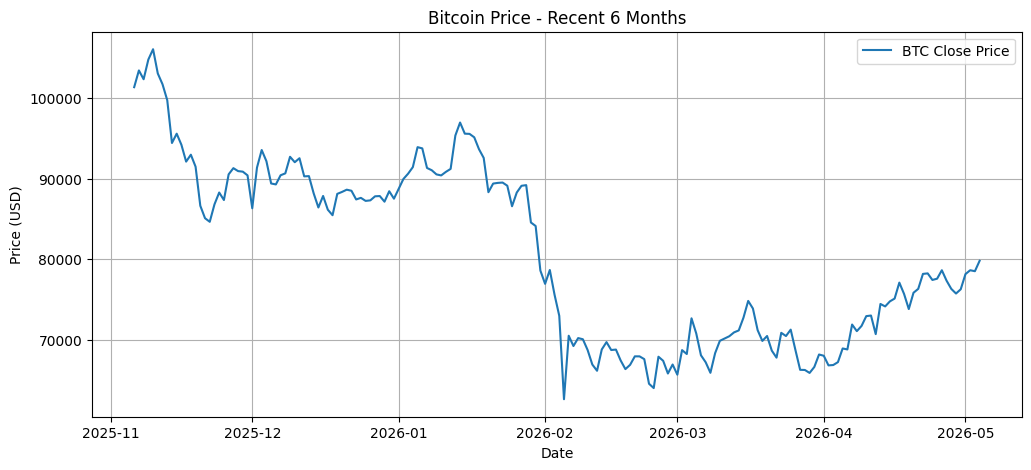

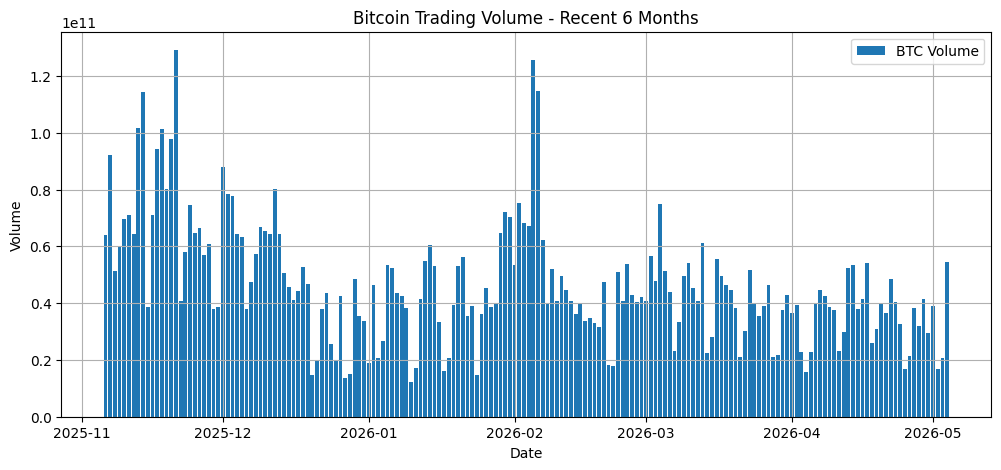

In [1]:
# 설치 코드
%pip install yfinance matplotlib pandas -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 비트코인 최근 가격 데이터 가져오기
btc = yf.download(
    "BTC-USD",
    period="6mo",
    interval="1d",
    auto_adjust=True
)

# yfinance 결과가 MultiIndex 컬럼으로 반환되는 경우 처리
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

# 필요한 컬럼만 사용
btc = btc[["Open", "High", "Low", "Close", "Volume"]]

# 결측치 제거
btc = btc.dropna()

# 데이터 확인
display(btc.head())
display(btc.tail())

# 종가 시각화
plt.figure(figsize=(12, 5))
plt.plot(btc.index, btc["Close"], label="BTC Close Price")

plt.title("Bitcoin Price - Recent 6 Months")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# 거래량 시각화
plt.figure(figsize=(12, 5))
plt.bar(btc.index, btc["Volume"].values, label="BTC Volume")

plt.title("Bitcoin Trading Volume - Recent 6 Months")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

## Gemini

[*********************100%***********************]  1 of 1 completed


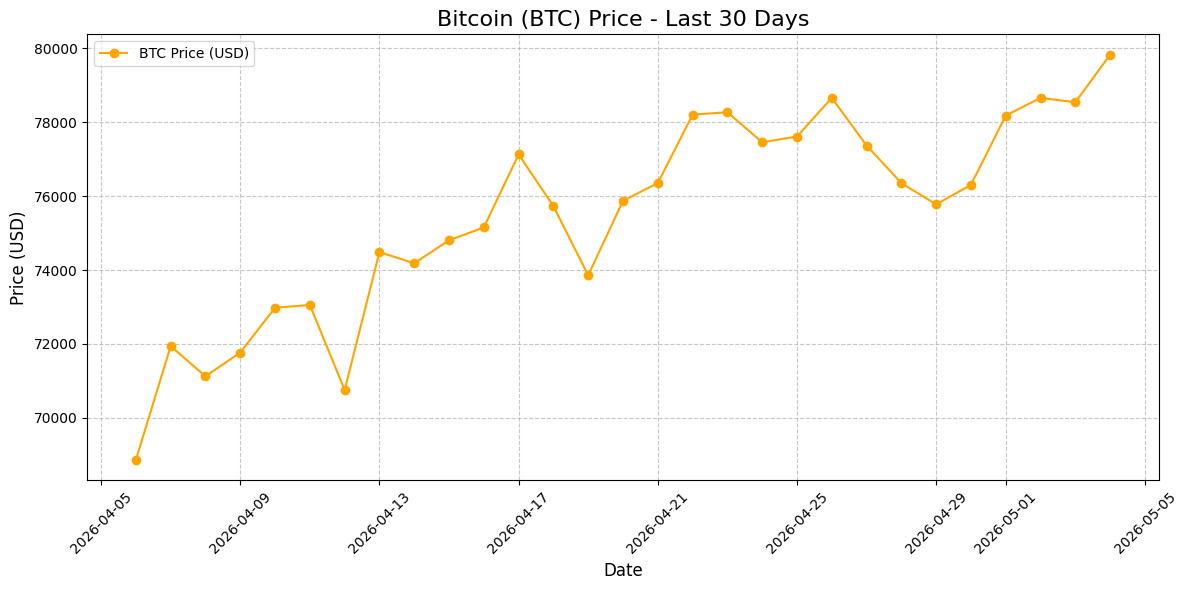

In [2]:
# 1. 필요한 라이브러리 설치
# !pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 2. 데이터 가져오기 (최근 30일간의 비트코인 데이터)
end_date = datetime.now()
start_date = end_date - timedelta(days=30)

# 비트코인(BTC-USD) 데이터 다운로드
btc_data = yf.download('BTC-USD', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Close'], marker='o', linestyle='-', color='orange', label='BTC Price (USD)')

# 그래프 꾸미기
plt.title('Bitcoin (BTC) Price - Last 30 Days', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

## Cluade

/var/folders/jm/m5h2gwtn6j160149_nsq1d7h0000gn/T/ipykernel_29527/413347254.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/jm/m5h2gwtn6j160149_nsq1d7h0000gn/T/ipykernel_29527/413347254.py:66: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.savefig("bitcoin_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
/var/folders/jm/m5h2gwtn6j160149_nsq1d7h0000gn/T/ipykernel_29527/413347254.py:66: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.savefig("bitcoin_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
/var/folders/jm/m5h2gwtn6j160149_nsq1d7h0000gn/T/ipykernel_29527/413347254.py:66: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.savefig("bitcoin_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolo

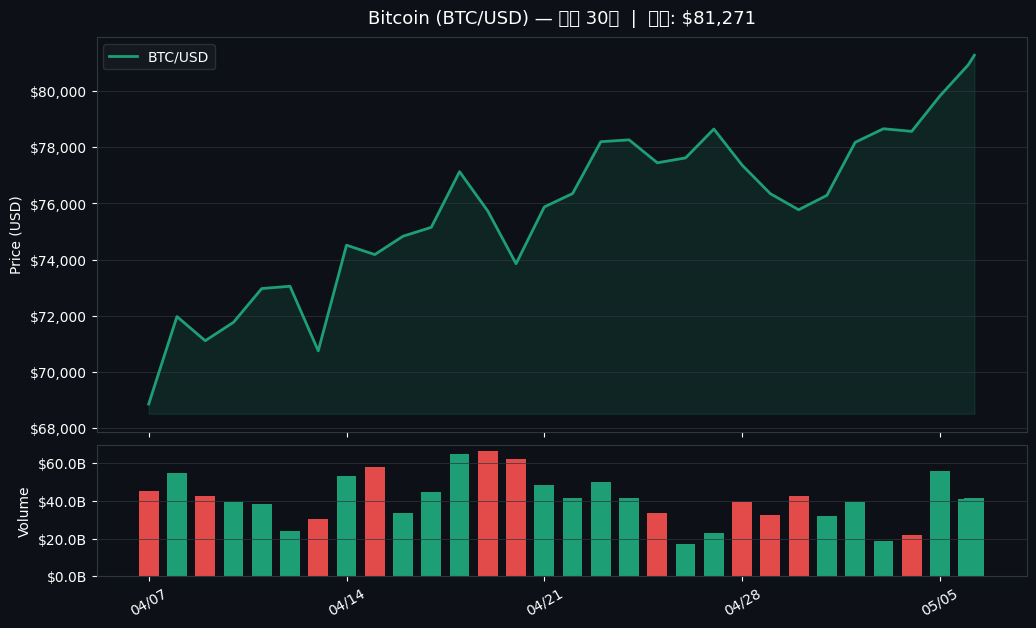

저장 완료: bitcoin_chart.png


In [3]:
# ── 1. 필요한 라이브러리 설치 ──────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "requests", "pandas", "matplotlib", "mplfinance"])

# ── 2. 임포트 ─────────────────────────────────────────────────────────────
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ── 3. CoinGecko API로 최근 30일 비트코인 데이터 수집 ──────────────────────
URL = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": 30, "interval": "daily"}

resp = requests.get(URL, params=params, timeout=10)
resp.raise_for_status()
data = resp.json()

# ── 4. DataFrame 변환 ─────────────────────────────────────────────────────
df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
df["date"]   = pd.to_datetime(df["timestamp"], unit="ms")
df["volume"] = [v[1] for v in data["total_volumes"]]
df = df[["date", "price", "volume"]].set_index("date")

# ── 5. 시각화 ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)
fig.patch.set_facecolor("#0d1117")
for ax in (ax1, ax2):
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#30363d")

# — 가격 선 차트 (상승/하락 색상 분리) ——
up   = df["price"] >= df["price"].iloc[0]
ax1.fill_between(df.index, df["price"], df["price"].min() * 0.995,
                 where=up,  alpha=0.15, color="#1D9E75")
ax1.fill_between(df.index, df["price"], df["price"].min() * 0.995,
                 where=~up, alpha=0.15, color="#E24B4A")
ax1.plot(df.index, df["price"], color="#1D9E75" if df["price"].iloc[-1] >= df["price"].iloc[0] else "#E24B4A",
         linewidth=2, label="BTC/USD")

ax1.set_ylabel("Price (USD)", color="white")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white")
ax1.set_title(f"Bitcoin (BTC/USD) — 최근 30일  |  현재: ${df['price'].iloc[-1]:,.0f}",
              color="white", fontsize=13, pad=10)
ax1.grid(axis="y", color="#30363d", linewidth=0.5)

# — 거래량 막대 차트 (하단) ——
vol_colors = ["#1D9E75" if df["price"].iloc[i] >= df["price"].iloc[i-1] else "#E24B4A"
              for i in range(len(df))]
ax2.bar(df.index, df["volume"], color=vol_colors, width=0.7)
ax2.set_ylabel("Volume", color="white")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B"))
ax2.grid(axis="y", color="#30363d", linewidth=0.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30, color="white")

plt.tight_layout()
plt.savefig("bitcoin_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("저장 완료: bitcoin_chart.png")

## LLM 평가

LMArena

https://lmarena.ai/

LMArena.ai는 대형 언어 모델(LLM)의 성능을 실제 사용자 참여 기반으로 평가·비교하는 개방형 벤치마킹 플랫폼이다. UC Berkeley 연구진이 주도하여 개발하였으며, 누구나 쉽게 최신 AI 모델을 직접 시험하고, 비교하고, 평가에 참여할 수 있도록 설계되어 있다.

### 핵심 특징

- 커뮤니티 기반 실시간 평가  
  사용자가 직접 입력한 프롬프트(질문)에 대해, 무작위로 선정된 두 개의 AI 모델이 응답을 생성한다. 사용자는 두 응답을 비교해 더 우수하다고 생각하는 쪽에 투표한다. 이 과정은 블라인드(익명)로 진행되어 편향을 최소화한다. 투표가 끝나면 어떤 모델이었는지 공개된다.

- Elo 레이팅 시스템  
  체스에서 사용하는 Elo 점수 시스템을 도입하여, 각 모델의 상대적 실력을 동적으로 산출한다. 강한 상대를 이기면 점수가 크게 오르고, 약한 상대에게 지면 점수가 크게 깎인다. 모든 모델의 점수와 순위는 리더보드에서 실시간으로 확인할 수 있다.

- 공정성과 투명성  
  플랫폼의 평가 시스템, 코드, 데이터 일부는 오픈소스로 공개되어 있다. 누구나 모델을 제출하거나 평가에 참여할 수 있다. 평가 데이터의 일부(최대 20%)는 연구와 커뮤니티 공유를 위해 공개된다.

- 다양한 모델 비교  
  GPT, Claude, LLaMA, Mistral 등 상용·오픈소스 모델을 모두 포함해 400개 이상의 모델이 등록되어 있다. 사전 공개(pre-release) 모델도 실험적으로 평가에 참여한다.

### 플랫폼의 작동 방식

1. 사용자가 프롬프트(질문)를 입력한다.  
2. 두 개의 익명 AI 모델이 각각 답변을 생성한다.  
3. 사용자는 두 답변을 비교해 더 나은 쪽에 투표한다(동점도 가능).  
4. 투표 후 모델의 정체가 공개된다.  
5. 결과는 Elo 시스템에 따라 점수에 반영되고, 리더보드에 실시간으로 반영된다.

### 플랫폼의 목적과 의의

- 기존의 정적 벤치마크(고정된 데이터셋, 자동화 지표)의 한계를 극복하고, 실제 사용자 경험과 선호도를 반영한 동적 평가를 지향한다.  
- 창의성, 유용성, 맥락 이해 등 자동화 지표로 측정하기 어려운 요소까지 평가할 수 있다.  
- 누구나 심사위원이 되어 AI 발전에 기여할 수 있는 공정하고 투명한 평가 생태계를 추구한다.